In [31]:
from matplotlib import pyplot as plt
import numpy as np
from scipy.signal import firwin

In [119]:
cfg = {}
cfg['dac_rate'] = 10e6 #Hz, sampling rate of output to DAC
cfg['freq_carrier'] = 5e6 #Hz, carrier frequency
cfg['code_baudrate'] = 200e3 #Hz, sampling rate for code

In [1]:
with open('images/ovro_resized.jpg', 'rb') as f:
    image_bytes = f.read()

In [4]:
byte_array = np.frombuffer(image_bytes, dtype=np.uint8)
bit_array = np.unpackbits(byte_array)
bit_array

array([1, 1, 1, ..., 0, 0, 1], shape=(4048,), dtype=uint8)

In [120]:
nbits=len(bit_array)
stretch=6
# we have 5 us chunks of carrier for each expanded code bit
per_code_len = int(5e-6 * stretch * len(bit_array) * cfg['dac_rate']) # 1 symbol every 5 us in units of ADC samples
print("per code len in samples", per_code_len)
carrier = 1e-4*np.cos(2*np.pi*cfg['freq_carrier']*np.arange(per_code_len)/cfg['dac_rate'])
# now reshape carrier into 16 parts. each part is now 1 bit repeated 6 times
code0 = carrier.reshape(nbits, -1)
for i in range(nbits):
    sign = int(bit_array[i])*2 - 1
    code0[i,:]*=sign
code0 = np.ravel(code0)

per code len in samples 1214400


In [129]:
code0 = np.hstack([np.zeros(4096),code0, np.zeros(4096)])

In [130]:
code0.nbytes/1e6

9.79712

filter +ve freq cutoff in units of sampling freq 0.02


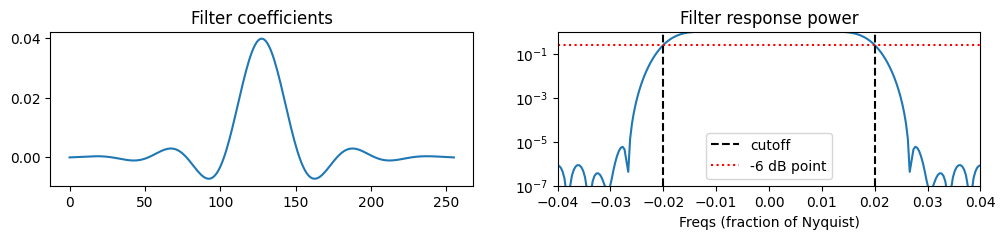

In [123]:
#first lets design a filter
cutoff = 200e3/cfg['dac_rate']
print("filter +ve freq cutoff in units of sampling freq", cutoff)
h = firwin(256, cutoff=cutoff, window='hamming',fs=1)
fig=plt.gcf()
fig.set_size_inches(12,2)
plt.subplot(121)
plt.title("Filter coefficients")
plt.plot(h)

plt.subplot(122)
plt.title("Filter response power")
filter_response = np.fft.fft( np.hstack([ h, np.zeros( 10*len(h) ) ]) ) 
#stack some zeros to increase freq resolution
freqs = np.fft.fftfreq(len(filter_response))
plt.semilogy( np.fft.fftshift(freqs),  np.fft.fftshift(np.abs(filter_response)**2))
plt.xlim(-cutoff-0.02, cutoff+0.02)
plt.axvline(cutoff, ls='dashed', c='black')
plt.axvline(-cutoff, ls='dashed', c='black',label='cutoff')
plt.axhline(0.25,ls='dotted', c='red',label='-6 dB point')
plt.xlabel("Freqs (fraction of Nyquist)")
plt.ylim(1e-7,1)
plt.legend()


In [131]:
x_dc = code0*np.exp(-2j*np.pi*cfg['freq_carrier']*np.arange(len(code0))/cfg['dac_rate'])

In [132]:
L = 4
ncols = L*256
nrows = x_dc.shape[0]//ncols
print(nrows, ncols)
x = x_dc[:nrows*ncols].reshape(nrows, ncols)
inp = np.zeros((nrows, (L+1)*256), dtype='complex128')
inp[0, 256:] = x[0, :L*256]
for i in range(nrows):
    inp[i, :256] = x[i-1,-256:]
    inp[i, 256:] = x[i, :L*256]
hf = np.fft.fft(np.hstack([h, np.zeros(L*256)]))
filt_inp = np.fft.ifft( np.fft.fft(inp,axis=1) * hf[None,:])
out = np.zeros((nrows, ncols),dtype='complex128')
for i in range(nrows):
    out[i, :] = filt_inp[i, 256:]
out = np.ravel(out)

1195 1024


In [133]:
out.shape

(1223680,)

In [134]:
y = out.real[::50]

In [138]:
idx = np.abs(y)>9e-6

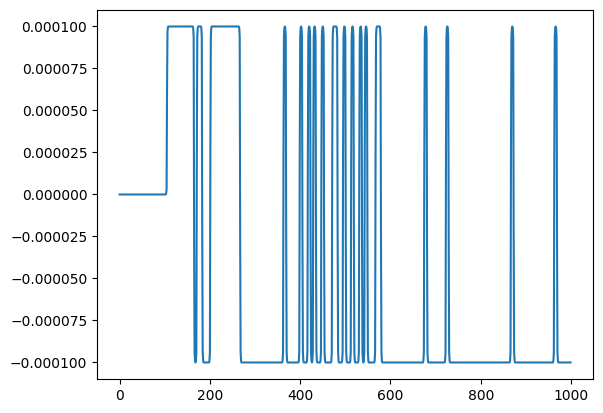

In [137]:
plt.plot(y[:1000])

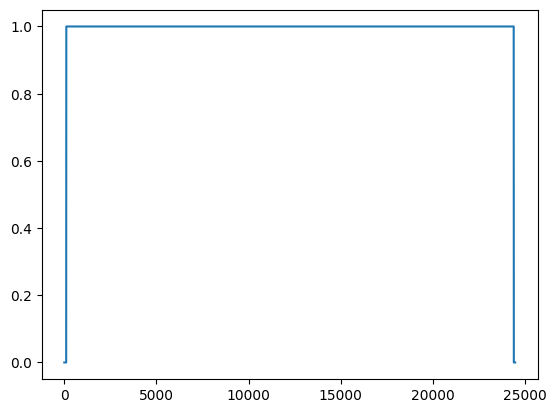

In [139]:
plt.plot(idx)

In [143]:
recovered_bits = y[idx][3::stretch] #get rid of bit repeats, stay away from edges

In [144]:
reconstructed_array = np.packbits(code1[3::stretch])

# 2. Convert the numpy array into a raw Python byte string
raw_byte_data = reconstructed_array.tobytes()

# 3. Write the raw binary data out to a file ('wb' stands for write-binary)
with open('images/recovered_image.jpg', 'wb') as f:
    f.write(raw_byte_data)